In [1]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images :", x_test.shape)
print("Testing Labels :", y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


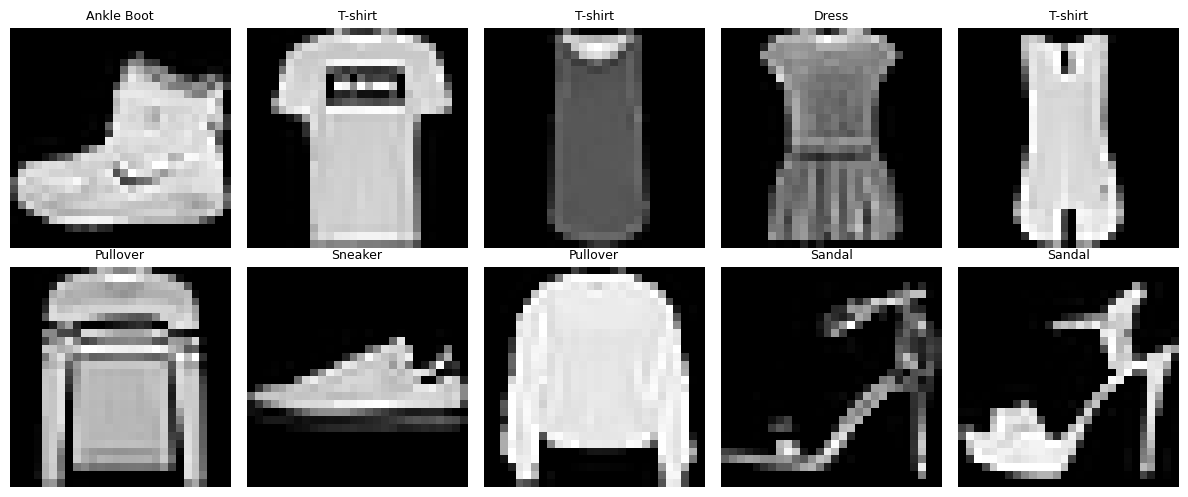

In [4]:
labels = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(labels[y_train[i]], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.savefig("sample_images.eps", format="eps")
plt.show()

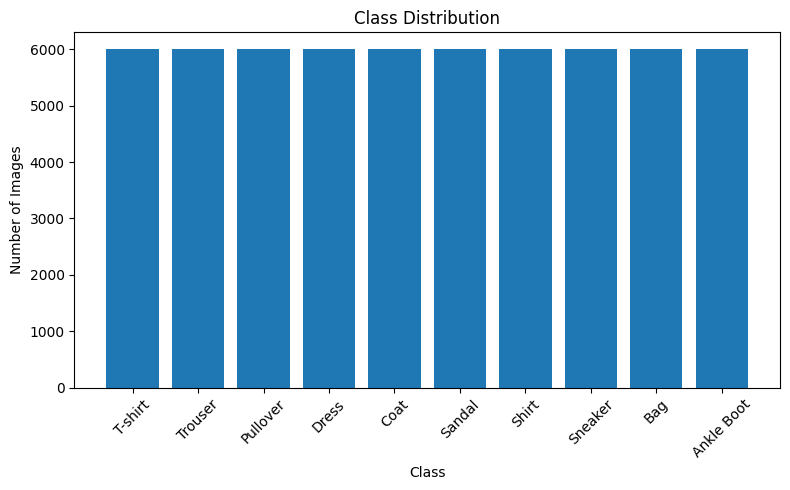

In [5]:
count = np.bincount(y_train)

plt.figure(figsize=(8,5))
plt.bar(labels, count)
plt.xticks(rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig("class_distribution.eps", format="eps")
plt.show()

In [6]:
print("Before Processing")

print(x_train.shape)
print(x_test.shape)

x_train = x_train.reshape(60000,784)
x_test = x_test.reshape(10000,784)

x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print()

print("After Processing")

print(x_train.shape)
print(x_test.shape)

print(y_train_cat.shape)
print(y_test_cat.shape)

Before Processing
(60000, 28, 28)
(10000, 28, 28)

After Processing
(60000, 784)
(10000, 784)
(60000, 10)
(10000, 10)


In [7]:
model = tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=(784,)))
model.add(tf.keras.layers.Dense(128, activation="relu"))
model.add(tf.keras.layers.Dense(64, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8198 - loss: 0.5072 - val_accuracy: 0.8450 - val_loss: 0.4268
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8638 - loss: 0.3768 - val_accuracy: 0.8608 - val_loss: 0.3776
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8765 - loss: 0.3381 - val_accuracy: 0.8651 - val_loss: 0.3664
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8855 - loss: 0.3131 - val_accuracy: 0.8739 - val_loss: 0.3509
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8905 - loss: 0.2935 - val_accuracy: 0.8757 - val_loss: 0.3585
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8971 - loss: 0.2771 - val_accuracy: 0.8763 - val_loss: 0.3491
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9018 - loss: 0.2635 - val_accuracy: 0.8748 - val_loss: 0.3511
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9058 - loss: 0.2535 

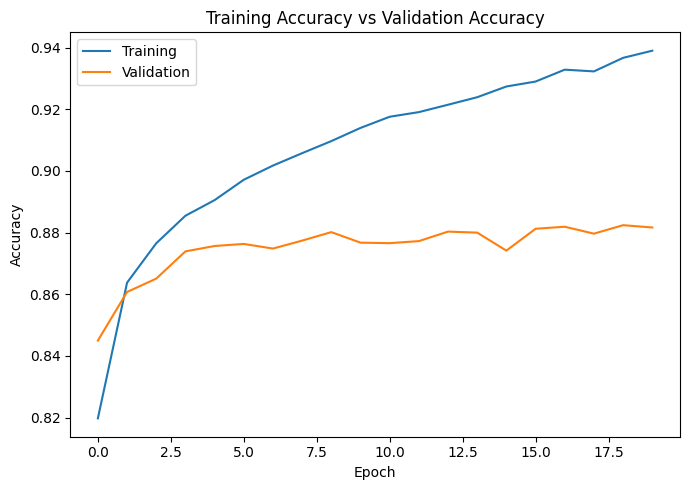

In [10]:
plt.figure(figsize=(7,5))
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Validation Accuracy")
plt.legend(["Training","Validation"])

plt.tight_layout()
plt.savefig("training_validation_accuracy.eps", format="eps")
plt.show()

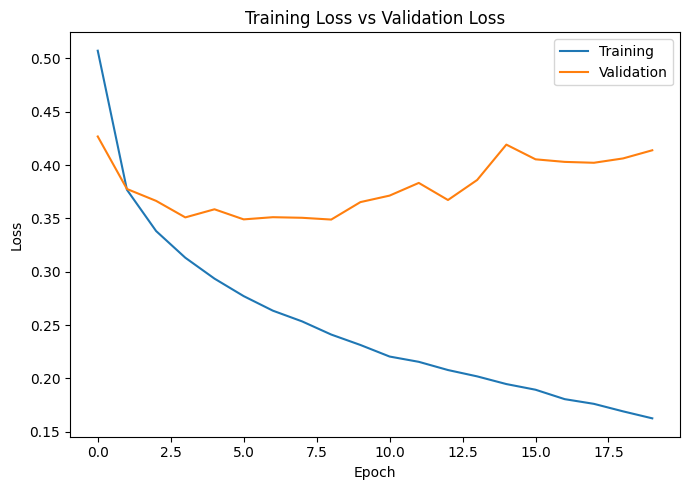

In [11]:
plt.figure(figsize=(7,5))
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend(["Training","Validation"])

plt.tight_layout()
plt.savefig("training_validation_loss.eps", format="eps")
plt.show()

In [12]:
loss, accuracy = model.evaluate(x_test, y_test_cat, verbose=0)

print("Testing Loss :", round(loss,4))
print("Testing Accuracy :", round(accuracy,4))

Testing Loss : 0.46
Testing Accuracy : 0.8723


In [13]:
pred = model.predict(x_test, verbose=0)

predicted = np.argmax(pred, axis=1)

acc = accuracy_score(y_test, predicted)
pre = precision_score(y_test, predicted, average="weighted")
rec = recall_score(y_test, predicted, average="weighted")
f1 = f1_score(y_test, predicted, average="weighted")

print("Accuracy :", round(acc,4))
print("Precision :", round(pre,4))
print("Recall :", round(rec,4))
print("F1 Score :", round(f1,4))

Accuracy : 0.8723
Precision : 0.8772
Recall : 0.8723
F1 Score : 0.8734


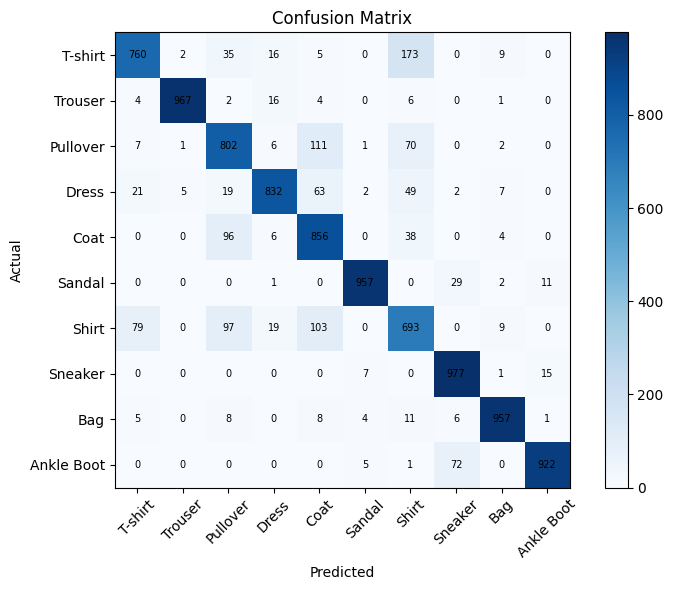

In [14]:
cm = confusion_matrix(y_test, predicted)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(range(10), labels, rotation=45)
plt.yticks(range(10), labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 fontsize=7)

plt.tight_layout()
plt.savefig("confusion_matrix.eps", format="eps")
plt.show()

In [15]:
print(classification_report(y_test, predicted, target_names=labels))

              precision    recall  f1-score   support

     T-shirt       0.87      0.76      0.81      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.76      0.80      0.78      1000
       Dress       0.93      0.83      0.88      1000
        Coat       0.74      0.86      0.80      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.67      0.69      0.68      1000
     Sneaker       0.90      0.98      0.94      1000
         Bag       0.96      0.96      0.96      1000
  Ankle Boot       0.97      0.92      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



In [16]:
!pip install -q scikeras==0.13.0

In [17]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

In [18]:
def build_model(hidden_layers=2,
                neurons=128,
                learning_rate=0.001,
                activation="relu",
                optimizer="adam",
                dropout_rate=0.0):

    model = Sequential()

    model.add(Input(shape=(784,)))
    model.add(Dense(neurons, activation=activation))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for _ in range(hidden_layers - 1):
        model.add(Dense(neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation="softmax"))

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [19]:
classifier = KerasClassifier(
    model=build_model,
    verbose=0
)

In [20]:
parameter_space = {

    "model__hidden_layers":[1,2,3],

    "model__neurons":[32,64,128],

    "model__learning_rate":[0.1,0.01,0.001],

    "model__activation":["relu","tanh"],

    "model__optimizer":["adam","sgd"],

    "model__dropout_rate":[0.0,0.2],

    "batch_size":[32,64],

    "epochs":[10,20]

}

In [23]:
search = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=parameter_space,
    n_iter=4,
    cv=3,
    random_state=42,
    scoring="accuracy",
    verbose=2,
    n_jobs=1
)

In [24]:
search.fit(x_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END batch_size=32, epochs=10, model__activation=relu, model__dropout_rate=0.2, model__hidden_layers=3, model__learning_rate=0.001, model__neurons=32, model__optimizer=adam; total time=  36.9s
[CV] END batch_size=32, epochs=10, model__activation=relu, model__dropout_rate=0.2, model__hidden_layers=3, model__learning_rate=0.001, model__neurons=32, model__optimizer=adam; total time=  32.5s
[CV] END batch_size=32, epochs=10, model__activation=relu, model__dropout_rate=0.2, model__hidden_layers=3, model__learning_rate=0.001, model__neurons=32, model__optimizer=adam; total time=  38.3s
[CV] END batch_size=64, epochs=10, model__activation=relu, model__dropout_rate=0.0, model__hidden_layers=1, model__learning_rate=0.1, model__neurons=64, model__optimizer=sgd; total time=  20.7s
[CV] END batch_size=64, epochs=10, model__activation=relu, model__dropout_rate=0.0, model__hidden_layers=1, model__learning_rate=0.1, model__neurons=64, mo

,estimator,KerasClassifi..._weight=None )
,param_distributions,"{'batch_size': [32, 64], 'epochs': [10, 20], 'model__activation': ['relu', 'tanh'], 'model__dropout_rate': [0.0, 0.2], ...}"
,n_iter,4
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
//import sklearn
//import scikeras
//print("Scikit-learn:", sklearn.__version__)
//print("SciKeras:", scikeras.__version__)

In [ ]:
//!pip install -q --upgrade scikit-learn==1.7.1

In [25]:
print("Best Parameters")
print(search.best_params_)

print()

print("Best Cross Validation Accuracy")
print(round(search.best_score_,4))

Best Parameters
{'model__optimizer': 'adam', 'model__neurons': 64, 'model__learning_rate': 0.001, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 20, 'batch_size': 64}

Best Cross Validation Accuracy
0.8751


In [26]:
best_model = search.best_estimator_

In [27]:
pred_best = best_model.predict(x_test)

acc_best = accuracy_score(y_test, pred_best)
pre_best = precision_score(y_test, pred_best, average="weighted")
rec_best = recall_score(y_test, pred_best, average="weighted")
f1_best = f1_score(y_test, pred_best, average="weighted")

print("Accuracy :", round(acc_best,4))
print("Precision :", round(pre_best,4))
print("Recall :", round(rec_best,4))
print("F1 Score :", round(f1_best,4))

Accuracy : 0.8764
Precision : 0.8772
Recall : 0.8764
F1 Score : 0.876


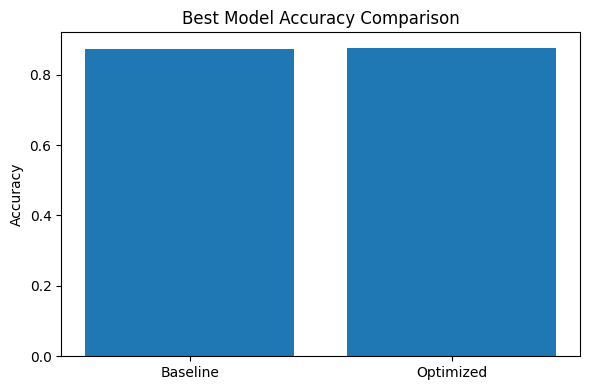

In [28]:
plt.figure(figsize=(6,4))

plt.bar(["Baseline","Optimized"], [acc, acc_best])

plt.ylabel("Accuracy")
plt.title("Best Model Accuracy Comparison")

plt.tight_layout()
plt.savefig("best_model_accuracy.eps", format="eps")

plt.show()

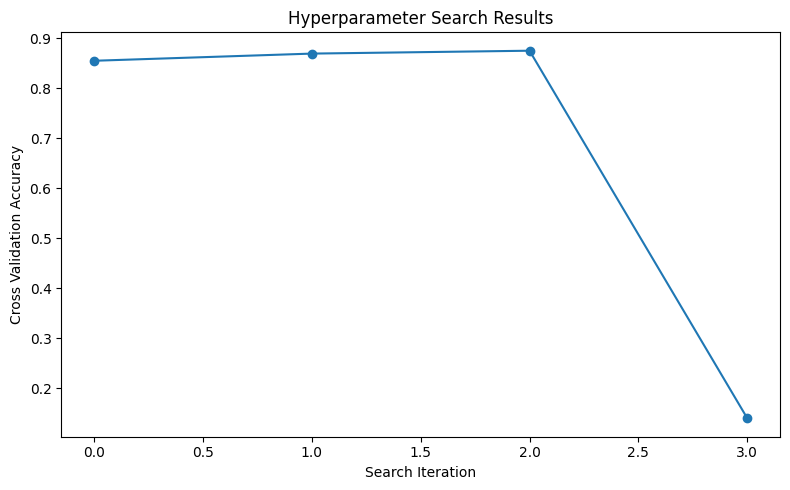

In [29]:
results = pd.DataFrame(search.cv_results_)

plt.figure(figsize=(8,5))

plt.plot(results["mean_test_score"], marker="o")

plt.xlabel("Search Iteration")
plt.ylabel("Cross Validation Accuracy")
plt.title("Hyperparameter Search Results")

plt.tight_layout()
plt.savefig("hyperparameter_search_results.eps", format="eps")

plt.show()